Two posts ago I ran [Falcon Perception + Gemma 4 on natural-scene images](2026-04-16-mlx-vlm-pr926.ipynb) and the pipeline worked nicely — 3-vs-3 became 3-vs-4 with mask receipts, drone traffic was countable per frame.

But Falcon and Gemma 4 are trained on natural images. What happens when you point them at *Sentinel-2 satellite tiles* with kilns the size of a few pixels?

[**SentinelKilnDB**](https://huggingface.co/datasets/SustainabilityLabIITGN/SentinelKilnDB) is a 114,300-tile dataset from our group at IIT Gandhinagar (NeurIPS 2025 D&B). 128×128 patches at 10 m/pixel covering the Indo-Gangetic Plain. Three brick-kiln classes:

- **CFCBK** — Continuous Fixed-Chimney Bull's-Trench Kiln (ring/oval shape with a central chimney)
- **FCBK** — Fixed-Chimney Bull's-Trench Kiln (rectangular, single chimney)
- **Zigzag** — Zigzag Kiln (rectangular with internal zigzag wall pattern)

I pulled **16 tiles** from the test split — 4 of each class plus 4 negatives — and put them through:

- Falcon Perception with two queries: `"brick kiln"` and `"small building"`
- Gemma 4 31B (4-bit MLX) as a one-shot classifier with the class definitions in the prompt

Everything runs locally on an M2 Max, in about three minutes.

## Pulling a small, balanced sample

In [1]:
import io, json
from pathlib import Path
from datasets import load_dataset
from PIL import Image

OUT = Path('sentinelkilndb/data')
WANT = 4    # 4 of each class + 4 negatives
ds = load_dataset('SustainabilityLabIITGN/SentinelKilnDB', split='test', streaming=True)

bucket = {'CFCBK': [], 'FCBK': [], 'Zigzag': [], 'negative': []}
for row in ds:
    img = Image.open(io.BytesIO(row['image'])).convert('RGB')
    dota = row.get('dota_label', [])
    if not dota:
        if len(bucket['negative']) < WANT:
            bucket['negative'].append(row['image_name'])
    else:
        cls = sorted({e['class'] for e in dota})[0]
        if len(bucket[cls]) < WANT:
            bucket[cls].append(row['image_name'])
    if all(len(v) >= WANT for v in bucket.values()):
        break
print({k: len(v) for k, v in bucket.items()})

{'CFCBK': 4, 'FCBK': 4, 'Zigzag': 4, 'negative': 4}


## Ground truth, upscaled

Each tile is 128×128 at 10 m/pixel. I upscaled to 512×512 for inspection (and for the models — Falcon was trained on much larger images). Class colours: **red** = CFCBK, **blue** = FCBK, **yellow** = Zigzag. The bottom row are negatives — note that the dataset's negatives include genuine no-kiln tiles *and* sensor-noise / no-data fills.

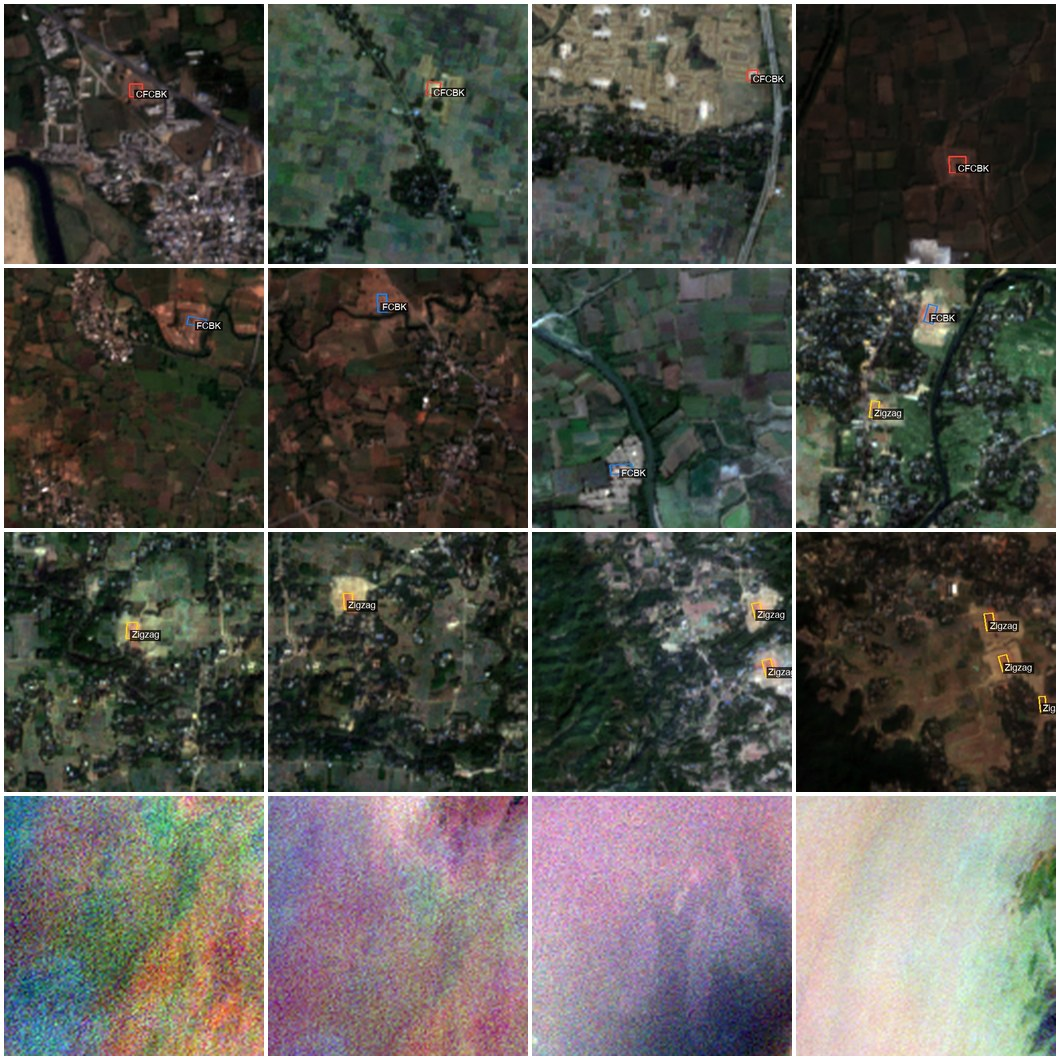

In [1]:
from IPython.display import Image as NBImage
NBImage('sentinelkilndb/outputs/gt_grid.jpg')

Even at 4× the original size, the kilns are tiny — most are 4 to 12 pixels per side in the source resolution. This is the visual budget Falcon and Gemma have to work with.

## Falcon Perception, zero-shot

Two queries, asked once per tile.

In [1]:
import sys; sys.path.insert(0, 'mlx_vlm_pr926')
from mlx_vlm import load
from fp_tools import run_ground_expression
from viz import render_som

fp_model, fp_processor = load('tiiuae/Falcon-Perception')

def run_query(img, query):
    masks = run_ground_expression(fp_model, fp_processor, img, query, max_new_tokens=256)
    return masks   # dict of mask metadata

# Loop over the 16 tiles, count detections per query (full code in repo)
...


Per-query summary across all 16 tiles:

- `"brick kiln"` returns at least one detection on **3/16** tiles (3/12 positives, 0/4 negatives).
- `"small building"` returns detections on **11/16** tiles — too generic to be useful as a kiln-specific signal.

### The two tiles where `"brick kiln"` actually fired

Index 03 — a CFCBK tile near a small town. The Falcon mask is on a bright structure that *could* be a kiln but is almost certainly the wrong object. Index 11 — a Zigzag tile with three GT boxes; Falcon found three masks here, but again on adjacent built-up patches, not the kiln rectangles themselves.

**Tile 03 — CFCBK** · GT (red) | Falcon `"brick kiln"` overlay

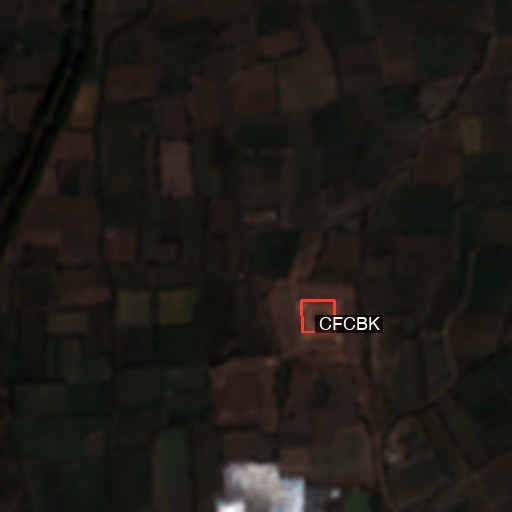

In [1]:
display(NBImage('sentinelkilndb/outputs/03_gt.jpg'))

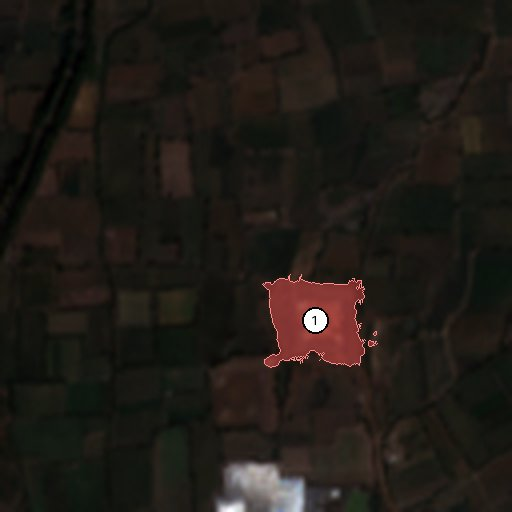

In [1]:
display(NBImage('sentinelkilndb/outputs/03_falcon_kiln.jpg'))

**Tile 11 — Zigzag** · GT (yellow) | Falcon `"brick kiln"` overlay

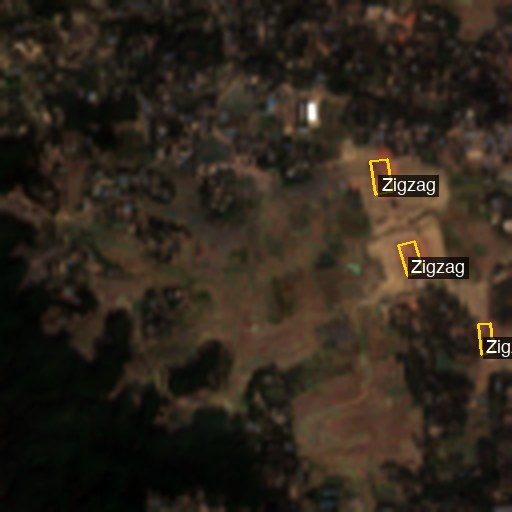

In [1]:
display(NBImage('sentinelkilndb/outputs/11_gt.jpg'))

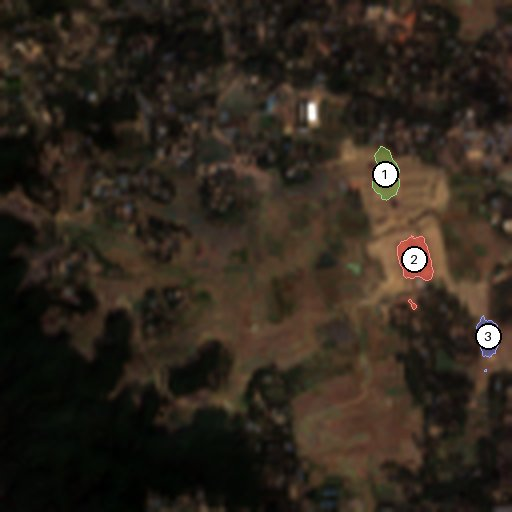

In [1]:
display(NBImage('sentinelkilndb/outputs/11_falcon_kiln.jpg'))

### All 16 Falcon overlays at a glance

Most tiles come back empty. The few that do have detections do not align with the GT boxes. This is honest behaviour — Falcon was not trained to recognise kilns from 10 m/pixel overhead imagery.

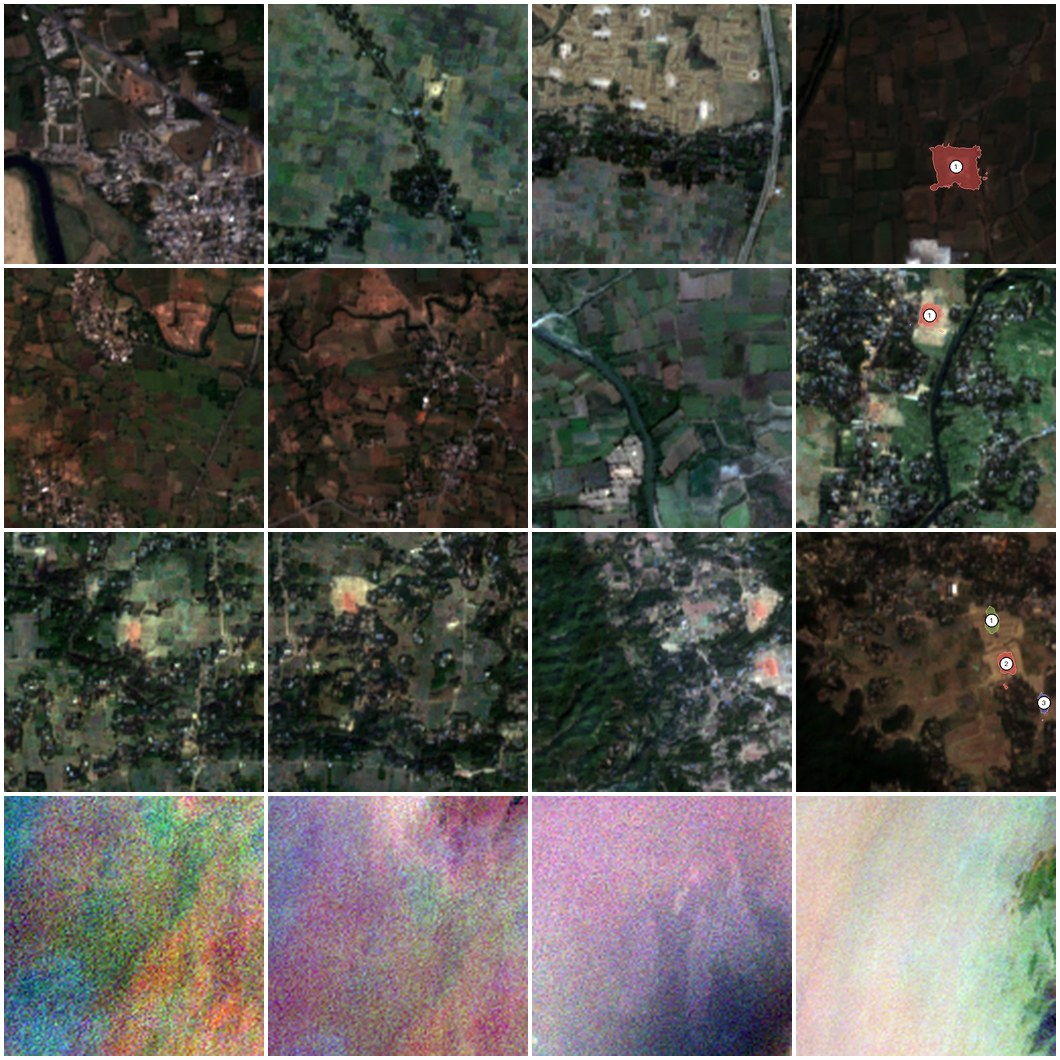

In [1]:
NBImage('sentinelkilndb/outputs/falcon_grid.jpg')

## Gemma 4 as a one-shot classifier

Same 16 tiles. I gave Gemma the class definitions in the prompt and asked for a structured JSON answer.

In [1]:
GEMMA_PROMPT = (
    'This is a 128x128 Sentinel-2 satellite tile (10 m/pixel) over South Asia, '
    'upscaled for inspection. The dataset distinguishes three brick-kiln types:\n'
    '  - CFCBK: continuous fixed-chimney bull\'s-trench kiln (ring/oval shape, central chimney)\n'
    '  - FCBK:  fixed-chimney bull\'s-trench kiln (rectangular, single chimney)\n'
    '  - Zigzag: zigzag kiln (rectangular with internal zigzag wall pattern)\n'
    'It may also contain no kiln at all.\n\n'
    'Answer in this exact JSON: {"present": true/false, '
    '"class": "CFCBK|FCBK|Zigzag|none", "confidence": "low|medium|high"}'
)

from agent import LocalVLMClient, run_baseline
vlm = LocalVLMClient('mlx-community/gemma-4-31b-it-4bit', max_tokens=512)
# answer = run_baseline(tile_512, GEMMA_PROMPT, vlm)   # one call per tile

### Results

| # | True class | GT boxes | Falcon `"brick kiln"` | Falcon `"small building"` | Gemma 4 prediction |
|---|------------|---------:|------------------------:|--------------------------:|--------------------|
| 00 | CFCBK | 1 | 0 | 0 | `none` |
| 01 | CFCBK | 1 | 0 | 1 | `none` |
| 02 | CFCBK | 1 | 0 | 13 | `CFCBK` |
| 03 | CFCBK | 1 | 1 | 1 | `none` |
| 04 | FCBK | 1 | 0 | 26 | `none` |
| 05 | FCBK | 1 | 0 | 85 | `none` |
| 06 | FCBK | 1 | 0 | 77 | `none` |
| 07 | FCBK | 2 | 1 | 50 | `none` |
| 08 | Zigzag | 1 | 0 | 1 | `none` |
| 09 | Zigzag | 1 | 0 | 36 | `none` |
| 10 | Zigzag | 2 | 0 | 0 | `none` |
| 11 | Zigzag | 3 | 3 | 0 | `none` |
| 12 | none | 0 | 0 | 1 | `none` |
| 13 | none | 0 | 0 | 1 | `none` |
| 14 | none | 0 | 0 | 0 | `none` |
| 15 | none | 0 | 0 | 0 | `none` |

**Overall accuracy: 5/16 = 31%** — and that headline number flatters the model. The breakdown by class is more telling:

| Class | Correct | Total |
|-------|--------:|------:|
| CFCBK | 1 | 4 |
| FCBK | 0 | 4 |
| Zigzag | 0 | 4 |
| none | 4 | 4 |

Gemma classifies the four negatives perfectly because it classifies *almost everything* as `none`. It only ventured a class once — `CFCBK` on tile 02 — and got it right.

That is not classification; that is a strong prior on `none` paying off when the negative class is well-represented. On the kiln tiles themselves Gemma's recall is **1/12** ≈ 8%.

## Why this is the expected outcome

It is tempting to read `0/4 FCBK` and conclude the models are broken. They are not. Three things are working *as designed*:

1. **Domain shift.** Falcon Perception was trained on natural-scene images where objects are large, photographed from human eye level, and described in everyday language. A 4-pixel-wide brick kiln viewed from 786 km up is none of those.
2. **Vocabulary shift.** "CFCBK" and "Zigzag kiln" are technical labels invented by remote-sensing and air-quality researchers. Gemma can repeat the words back, but the *visual prototype* it associates with "brick kiln" is a backyard pile of bricks, not a 200 m × 100 m oval rendered as a smudge.
3. **Resolution shift.** At 10 m/pixel a 100 m kiln is a 10×10 region. Falcon's encoder was not asked to discriminate at that scale.

The outcome is exactly the use case for SentinelKilnDB: a domain-specific labelled benchmark exists *because* zero-shot models fail this test.

## What this small probe is good for

- **Sanity check before fine-tuning.** Knowing a baseline gets near-zero recall makes a fine-tuned head easy to celebrate.
- **Cheap negative-class auditing.** The four negatives were all called `none` by both models; that confirms the dataset's negatives are visually distinguishable, not adversarially close.
- **Calibrating expectations.** If you are tempted to wire Falcon Perception into a remote-sensing pipeline, this is the trial run that tells you to fine-tune first.

## Cost

16 tiles × (Falcon × 2 queries + Gemma × 1 call) = ~3 minutes wall clock on an M2 Max with 64 GB. Models loaded once, reused across all 16.

## Links

- Dataset: [`SustainabilityLabIITGN/SentinelKilnDB`](https://huggingface.co/datasets/SustainabilityLabIITGN/SentinelKilnDB) · [paper (NeurIPS 2025 D&B)](https://openreview.net/forum?id=efGzsxVSEC)
- mlx-vlm PR with the agent code: [Blaizzy/mlx-vlm#926](https://github.com/Blaizzy/mlx-vlm/pull/926)
- Falcon Perception: [`tiiuae/Falcon-Perception`](https://huggingface.co/tiiuae/Falcon-Perception)
- Companion post on natural images: [Grounded Visual Reasoning on a Mac](2026-04-16-mlx-vlm-pr926.ipynb)
